**Installing Dependencies**

In [ ]:
!pip install pandas numpy torch matplotlib seaborn scikit-learn transformers datasets evaluate accelerate openpyxl

**Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC

from transformers import(
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

from datasets import Dataset
from evaluate import load

In [ ]:
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


**Data Importing from Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_a = pd.read_csv('/content/drive/MyDrive/UrduFakeNews/df_a.csv')
print("df_a head:")
display(df_a.head())

df_a head:


,text,label,source
0,بہار انتخابات: آر جے ڈی کی پہلی فہرست میں 42 ا...,1,ax_to_grind
1,گوگل کا پہلا دفتر کھلا ، سیکٹر جی 9 ، اسلام آب...,0,ax_to_grind
2,طبی عملے کو خوش کرتے دکھاتے ہوئے ویڈیو نیوزی ل...,0,ax_to_grind
3,جموں و کشمیر میں پاکستان کی جانب سے جنگ بندی ک...,0,ax_to_grind
4,ہ تصویر مصر میں بنے ایک غیر قانونی گھر کی ہے ج...,0,ax_to_grind


In [ ]:
df_b = pd.read_csv('/content/drive/MyDrive/UrduFakeNews/df_b.csv')
print("df_b head:")
display(df_b.head())

df_b head:


,text,label,source
0,کراچی92نیوزماہی گیری اور مچھلیوں کی افزائش کے ...,0,notri_fact
1,کراچی 92 نیوز پاکستان موٹر ڈیلرز ایسوسی ایشن ک...,1,notri_fact
2,لندنسپورٹس ڈیسککھیل کی دنیا میں کبھی کبھی ایسے...,0,notri_fact
3,ٹوکیو 92 نیوز جاپان میں دنیا کا سب سے ننھا اسپ...,1,notri_fact
4,نئی دہلیسپورٹس ڈیسکبلائنڈ ٹی ٹونٹی ورلڈ کپ میں...,0,notri_fact


In [ ]:
model_path = '/content/drive/MyDrive/UrduFakeNews/exp1_model'

tokenizer = AutoTokenizer.from_pretrained(model_path)
print("Tokenizer loaded successfully.")

Tokenizer loaded successfully.


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.to(DEVICE)
print("Model loaded successfully and moved to device:", DEVICE)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded successfully and moved to device: cuda


In [ ]:
def tokenize_fn(examples):
    return tokenizer(examples['text'], truncation=True, padding=True)

**Training on Dataset B**

In [ ]:
train_b, test_b = train_test_split(
    df_b,
    test_size=0.2,
    random_state=SEED,
    stratify=df_b['label']
)

print("Train size:", len(train_b))
print("Test size: ", len(test_b))
print("Train label distribution:", train_b['label'].value_counts().to_dict())
print("Test label distribution: ", test_b['label'].value_counts().to_dict())

Train size: 10710
Test size:  2678
Train label distribution: {0: 5369, 1: 5341}
Test label distribution:  {0: 1342, 1: 1336}


In [ ]:
train_ds_b = Dataset.from_pandas(train_b[['text', 'label']].reset_index(drop=True))
test_ds_b  = Dataset.from_pandas(test_b[['text', 'label']].reset_index(drop=True))

train_ds_b = train_ds_b.map(tokenize_fn, batched=True)
test_ds_b  = test_ds_b.map(tokenize_fn, batched=True)

train_ds_b.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_ds_b.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

print("Tokenization done")

Map:   0%|          | 0/10710 [00:00<?, ? examples/s]

Map:   0%|          | 0/2678 [00:00<?, ? examples/s]

Tokenization done


In [ ]:
training_args_2 = TrainingArguments(
    output_dir="./exp2_notri_fact",
    num_train_epochs=3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 16,
    learning_rate = 2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    seed=SEED,
    logging_steps=50,
)

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")
print("Data collator initialized.")

Data collator initialized.


In [ ]:
metric = load("f1")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(predictions=predictions, references=labels)

print("Compute metrics function defined.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Compute metrics function defined.


In [ ]:
model_2 = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    num_labels=2
)

trainer_2 = Trainer(
    model=model_2,
    args=training_args_2,
    train_dataset=train_ds_b,
    eval_dataset=test_ds_b,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer_2.train()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,F1
1,0.187788,0.194387,0.949772
2,0.158070,0.197330,0.952381
3,0.179246,0.185730,0.953672


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2010, training_loss=0.18769170425424528, metrics={'train_runtime': 3948.8787, 'train_samples_per_second': 8.136, 'train_steps_per_second': 0.509, 'total_flos': 8453758208716800.0, 'train_loss': 0.18769170425424528, 'epoch': 3.0})

In [ ]:
results_2 = trainer_2.evaluate(test_ds_b)
print("Experiment 2 In-domain Notri-Fact")
for k, v in results_2.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Experiment 2 In-domain Notri-Fact
  eval_loss: 0.1857
  eval_f1: 0.9537
  eval_runtime: 91.6543
  eval_samples_per_second: 29.2180
  eval_steps_per_second: 1.8330
  epoch: 3.0000


**Testing of Dataset B on Dataset A**

In [ ]:
full_ds_b = Dataset.from_pandas(df_b[['text', 'label']].reset_index(drop=True))
full_ds_b = full_ds_b.map(tokenize_fn, batched=True)
full_ds_b.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

trainer_exp3 = Trainer(
    model=model,
    args=TrainingArguments(output_dir="./exp3", per_device_eval_batch_size=16, seed=SEED),
    compute_metrics=compute_metrics,
)

results_3 = trainer_exp3.evaluate(full_ds_b)
print("Experiment 3: Cross-domain A to B (trained on Ax-to-Grind, tested on Notri-Fact)")
for k, v in results_3.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Map:   0%|          | 0/13388 [00:00<?, ? examples/s]

Experiment 3: Cross-domain A to B (trained on Ax-to-Grind, tested on Notri-Fact)
  eval_loss: 3.3246
  eval_model_preparation_time: 0.0044
  eval_f1: 0.0054
  eval_runtime: 445.2913
  eval_samples_per_second: 30.0660
  eval_steps_per_second: 1.8800


In [ ]:
preds_3 = trainer_exp3.predict(full_ds_b)
pred_labels = np.argmax(preds_3.predictions, axis=-1)
print("Predicted label distribution:", np.unique(pred_labels, return_counts=True))
print("Actual label distribution:", np.unique(preds_3.label_ids, return_counts=True))

Predicted label distribution: (array([0, 1]), array([13350,    38]))
Actual label distribution: (array([0, 1]), array([6711, 6677]))


**Testing of Dataset A on Dataset B**

In [ ]:
full_ds_a = Dataset.from_pandas(df_a[['text', 'label']].reset_index(drop=True))
full_ds_a = full_ds_a.map(tokenize_fn, batched=True)
full_ds_a.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

trainer_exp4 = Trainer(
    model=model_2,
    args=TrainingArguments(output_dir="./exp4", per_device_eval_batch_size=16, seed=SEED),
    compute_metrics=compute_metrics,
)

results_4 = trainer_exp4.evaluate(full_ds_a)
print("Experiment 4: Cross-domain B to A (trained on Notri-Fact, tested on Ax-to-Grind)")
for k, v in results_4.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Map:   0%|          | 0/9235 [00:00<?, ? examples/s]

Experiment 4: Cross-domain B to A (trained on Notri-Fact, tested on Ax-to-Grind)
  eval_loss: 1.0553
  eval_model_preparation_time: 0.0027
  eval_f1: 0.7707
  eval_runtime: 295.8285
  eval_samples_per_second: 31.2170
  eval_steps_per_second: 1.9540


**Text Preprocessing**

In [ ]:
!pip install nltk
import nltk
import re
import string

urdu_stopwords = set([
    'کا', 'کی', 'کے', 'میں', 'ہے', 'ہیں', 'نے', 'کو', 'سے', 'پر',
    'اور', 'یہ', 'وہ', 'ایک', 'بھی', 'تو', 'ہو', 'کہ', 'جو', 'اس',
    'اب', 'تھا', 'تھی', 'تھے', 'گا', 'گی', 'گے', 'لیے', 'ان', 'اپنے',
    'ہوئے', 'ہوئی', 'ہونے', 'والے', 'والی', 'والا', 'رہا', 'رہی', 'رہے',
    'جب', 'تب', 'پھر', 'مگر', 'لیکن', 'یا', 'نہیں', 'نہ', 'ہی', 'تک'
])

urdu_punctuation = '،؟؛۔٪'

def clean_text_urdu(text):
    text = str(text)
    text = re.sub(r'[%s]' % re.escape(urdu_punctuation), ' ', text)

    text = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', text)

    text = re.sub(r'[\d۰-۹]', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()
    words = [w for w in words if w not in urdu_stopwords]
    return ' '.join(words)

df_a['text_clean'] = df_a['text'].apply(clean_text_urdu)
df_b['text_clean'] = df_b['text'].apply(clean_text_urdu)

print("Urdu cleaning done.")
print(df_a['text_clean'].head(2))

Urdu cleaning done.
0    بہار انتخابات آر جے ڈی پہلی فہرست امیدواروں نام
1    گوگل پہلا دفتر کھلا سیکٹر جی اسلام آباد پاکستان
Name: text_clean, dtype: object


In [ ]:
!pip install arabic_reshaper python-bidi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 11.1 MB/s eta 0:00:00


In [ ]:
import arabic_reshaper
from bidi.algorithm import get_display
import matplotlib.font_manager as fm

# Download and install an Arabic font
!wget https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansArabic/NotoSansArabic-Regular.ttf -O /usr/share/fonts/truetype/noto/NotoSansArabic-Regular.ttf
!fc-cache -f -v

# Configure matplotlib to use the Arabic font
fm.fontManager.addfont('/usr/share/fonts/truetype/noto/NotoSansArabic-Regular.ttf')
plt.rcParams['font.family'] = 'Noto Sans Arabic'
plt.rcParams['font.size'] = 12

print("Arabic rendering libraries installed and matplotlib configured.")

### Word Frequency Analysis (Corrected Arabic Rendering)

/tmp/ipykernel_3552/2152420488.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=words_display, y=counts, palette='viridis')
/tmp/ipykernel_3552/2152420488.py:21: UserWarning: Glyph 64431 (\N{ARABIC LETTER YEH BARREE FINAL FORM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3552/2152420488.py:21: UserWarning: Glyph 64425 (\N{ARABIC LETTER HEH GOAL MEDIAL FORM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3552/2152420488.py:21: UserWarning: Glyph 64422 (\N{ARABIC LETTER HEH GOAL ISOLATED FORM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3552/2152420488.py:21: UserWarning: Glyph 64430 (\N{ARABIC LETTER YEH BARREE ISOLATED FORM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: User

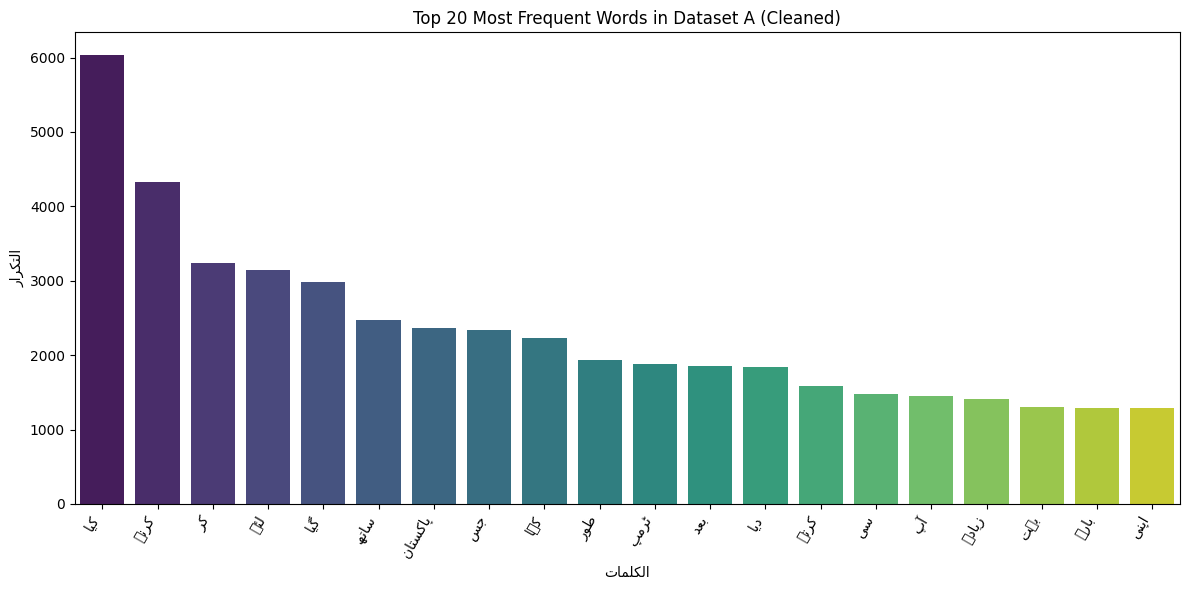

/tmp/ipykernel_3552/2152420488.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=words_display, y=counts, palette='viridis')
/tmp/ipykernel_3552/2152420488.py:21: UserWarning: Glyph 64431 (\N{ARABIC LETTER YEH BARREE FINAL FORM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 64431 (\N{ARABIC LETTER YEH BARREE FINAL FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


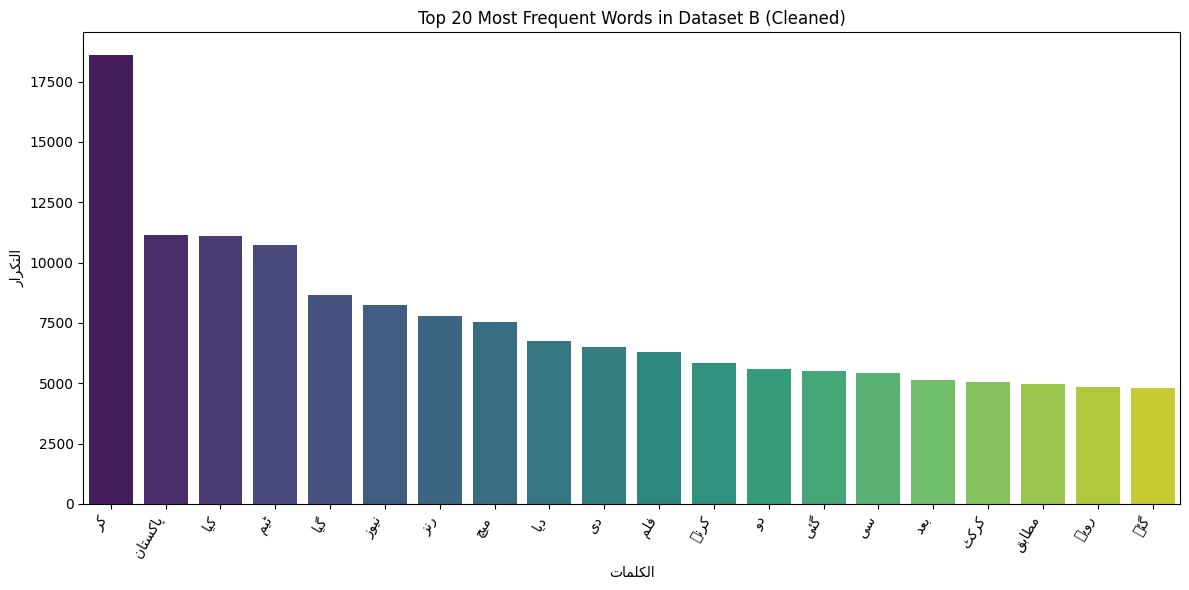

In [ ]:
from collections import Counter
import itertools
import arabic_reshaper
from bidi.algorithm import get_display

def plot_word_frequency(df, title):
    all_words = list(itertools.chain.from_iterable(df['text_clean'].apply(lambda x: str(x).split())))
    word_counts = Counter(all_words)
    most_common_words = word_counts.most_common(20)

    words_raw = [word for word, count in most_common_words]
    words_display = [get_display(arabic_reshaper.reshape(word)) for word in words_raw]
    counts = [count for word, count in most_common_words]

    plt.figure(figsize=(12, 6))
    sns.barplot(x=words_display, y=counts, palette='viridis')
    plt.title(get_display(arabic_reshaper.reshape(title)))
    plt.xlabel(get_display(arabic_reshaper.reshape('الكلمات')))
    plt.ylabel(get_display(arabic_reshaper.reshape('التكرار')))
    plt.xticks(rotation=60, ha='right')
    plt.tight_layout()
    plt.show()

plot_word_frequency(df_a, 'Top 20 Most Frequent Words in Dataset A (Cleaned)')
plot_word_frequency(df_b, 'Top 20 Most Frequent Words in Dataset B (Cleaned)')

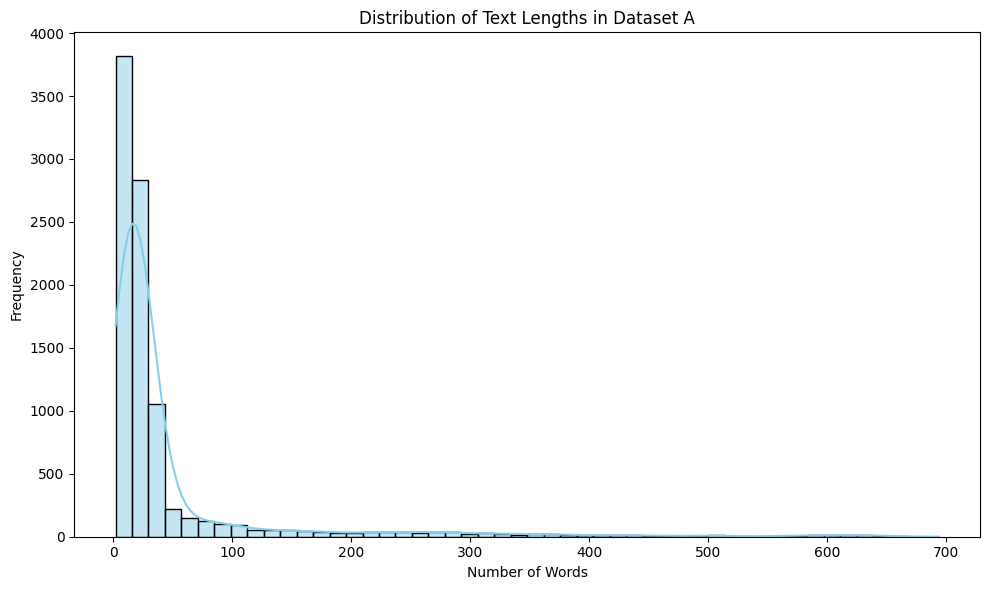

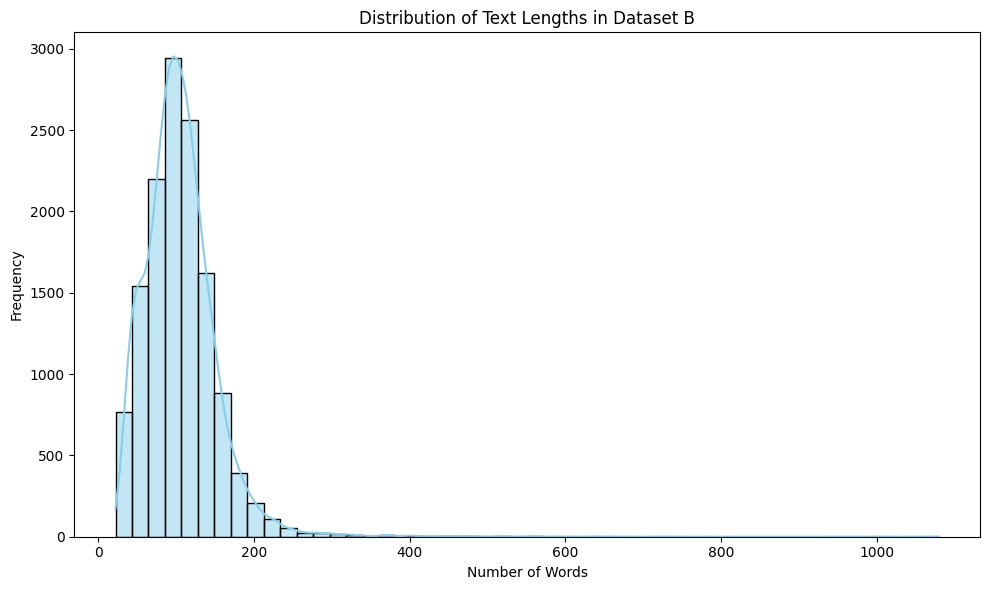

In [ ]:
def plot_text_length_distribution(df, title):
    df['text_length'] = df['text_clean'].apply(lambda x: len(str(x).split()))

    plt.figure(figsize=(10, 6))
    sns.histplot(df['text_length'], bins=50, kde=True, color='skyblue')
    plt.title(title)
    plt.xlabel('Number of Words')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

plot_text_length_distribution(df_a, 'Distribution of Text Lengths in Dataset A')
print('\n')
plot_text_length_distribution(df_b, 'Distribution of Text Lengths in Dataset B')

### Label Distribution

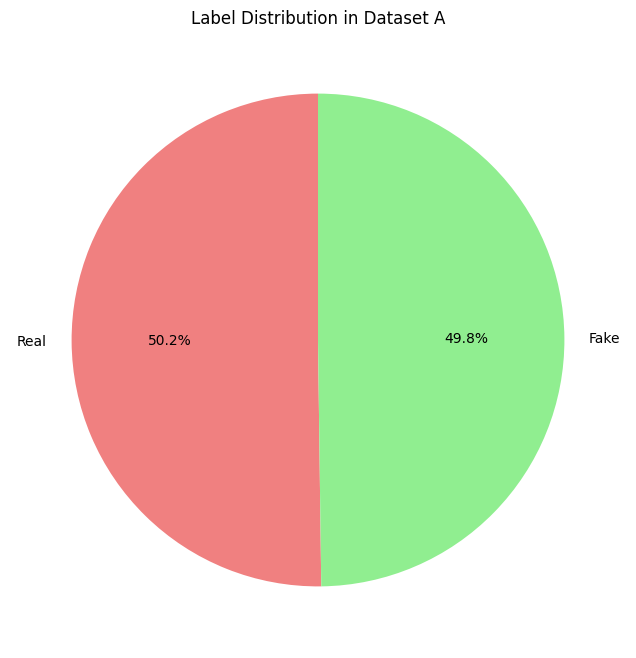

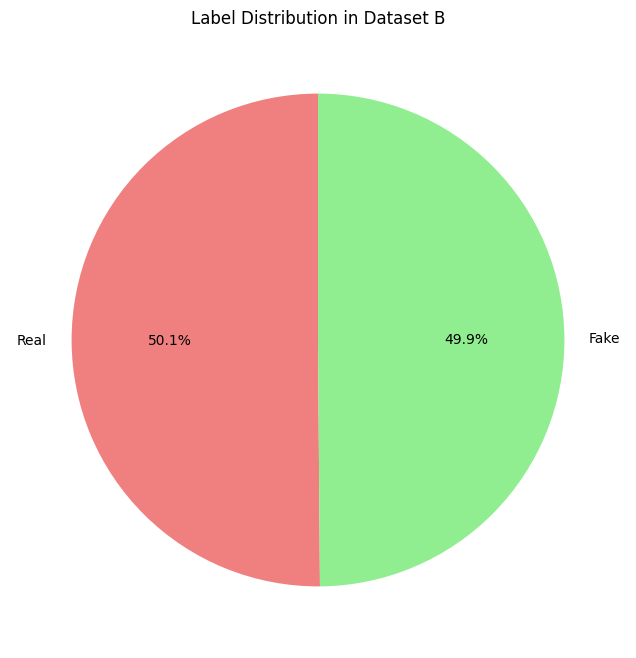

In [ ]:
def plot_label_distribution(df, title):
    label_counts = df['label'].value_counts()
    labels = ['Fake' if i == 1 else 'Real' for i in label_counts.index]

    plt.figure(figsize=(8, 8))
    plt.pie(label_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightgreen'])
    plt.title(title)
    plt.show()

plot_label_distribution(df_a, 'Label Distribution in Dataset A')
print('\n')
plot_label_distribution(df_b, 'Label Distribution in Dataset B')

**TF-IDF and ML Models**

In [ ]:
train_a_tfidf, test_a_tfidf = train_test_split(df_a, test_size=0.2, random_state=SEED, stratify=df_a['label'])

tfidf_a = TfidfVectorizer(max_features=10000)
X_train_a = tfidf_a.fit_transform(train_a_tfidf['text_clean'])
X_test_a  = tfidf_a.transform(test_a_tfidf['text_clean'])
y_train_a = train_a_tfidf['label']
y_test_a  = test_a_tfidf['label']

lr_a = LogisticRegression(max_iter=1000, random_state=SEED)
lr_a.fit(X_train_a, y_train_a)
print("---- TF-IDF + Logistic Regression: Dataset A ----")
print(classification_report(y_test_a, lr_a.predict(X_test_a)))

svm_a = SVC(kernel='linear', random_state=SEED)
svm_a.fit(X_train_a, y_train_a)
print("---- TF-IDF + SVM: Dataset A ----")
print(classification_report(y_test_a, svm_a.predict(X_test_a)))

---- TF-IDF + Logistic Regression: Dataset A ----
              precision    recall  f1-score   support

           0       0.87      0.83      0.85       927
           1       0.84      0.88      0.86       920

    accuracy                           0.86      1847
   macro avg       0.86      0.86      0.86      1847
weighted avg       0.86      0.86      0.86      1847

---- TF-IDF + SVM: Dataset A ----
              precision    recall  f1-score   support

           0       0.86      0.85      0.85       927
           1       0.85      0.86      0.86       920

    accuracy                           0.85      1847
   macro avg       0.85      0.85      0.85      1847
weighted avg       0.86      0.85      0.85      1847



In [ ]:
train_b_tfidf, test_b_tfidf = train_test_split(df_b, test_size=0.2, random_state=SEED, stratify=df_b['label'])

tfidf_b = TfidfVectorizer(max_features=10000)
X_train_b = tfidf_b.fit_transform(train_b_tfidf['text_clean'])
X_test_b  = tfidf_b.transform(test_b_tfidf['text_clean'])
y_train_b = train_b_tfidf['label']
y_test_b  = test_b_tfidf['label']

lr_b = LogisticRegression(max_iter=1000, random_state=SEED)
lr_b.fit(X_train_b, y_train_b)
print("---- TF-IDF + Logistic Regression: Dataset B ----")
print(classification_report(y_test_b, lr_b.predict(X_test_b)))

svm_b = SVC(kernel='linear', random_state=SEED)
svm_b.fit(X_train_b, y_train_b)
print("---- TF-IDF + SVM: Dataset B ----")
print(classification_report(y_test_b, svm_b.predict(X_test_b)))

---- TF-IDF + Logistic Regression: Dataset B ----
              precision    recall  f1-score   support

           0       0.90      0.89      0.90      1342
           1       0.89      0.91      0.90      1336

    accuracy                           0.90      2678
   macro avg       0.90      0.90      0.90      2678
weighted avg       0.90      0.90      0.90      2678

---- TF-IDF + SVM: Dataset B ----
              precision    recall  f1-score   support

           0       0.92      0.90      0.91      1342
           1       0.90      0.92      0.91      1336

    accuracy                           0.91      2678
   macro avg       0.91      0.91      0.91      2678
weighted avg       0.91      0.91      0.91      2678



### Confusion Matrices for Traditional ML Models

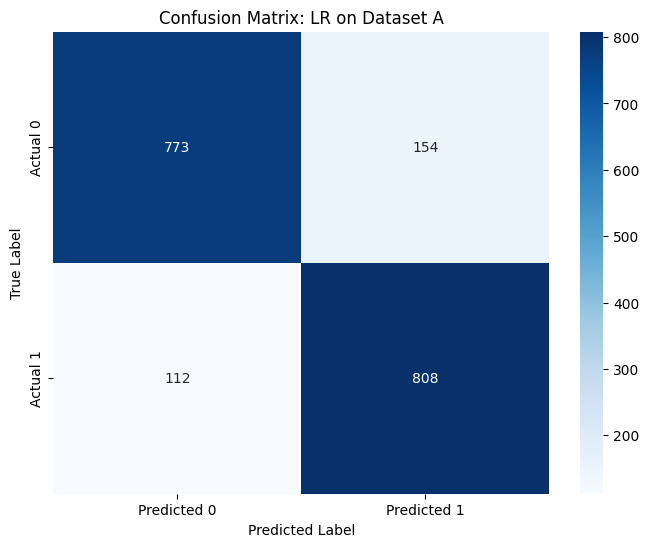

In [ ]:
plt.figure(figsize=(8, 6))
cm_lr_a = confusion_matrix(y_test_a, lr_a_preds)
sns.heatmap(cm_lr_a, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix: LR on Dataset A')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

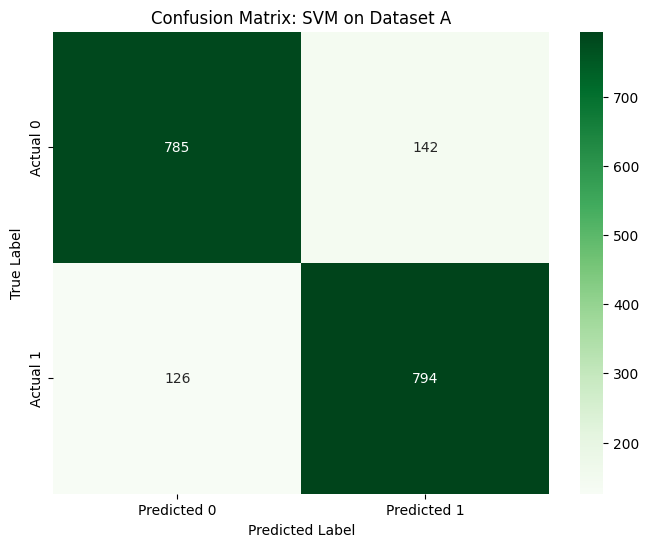

In [ ]:
plt.figure(figsize=(8, 6))
cm_svm_a = confusion_matrix(y_test_a, svm_a_preds)
sns.heatmap(cm_svm_a, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix: SVM on Dataset A')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

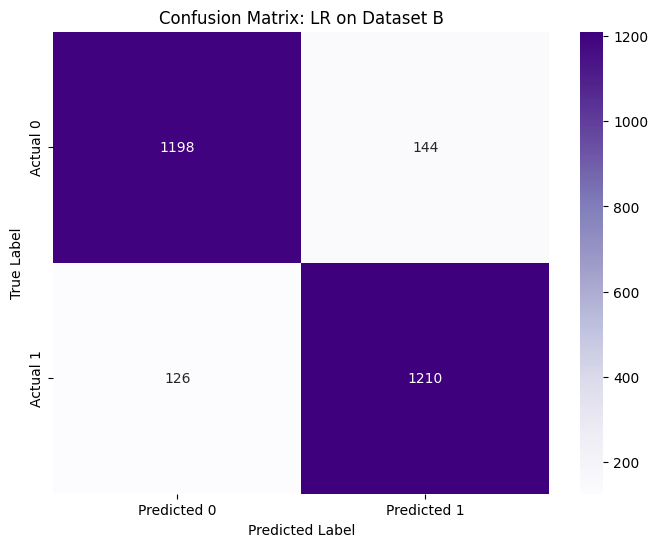

In [ ]:
plt.figure(figsize=(8, 6))
cm_lr_b = confusion_matrix(y_test_b, lr_b_preds)
sns.heatmap(cm_lr_b, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix: LR on Dataset B')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

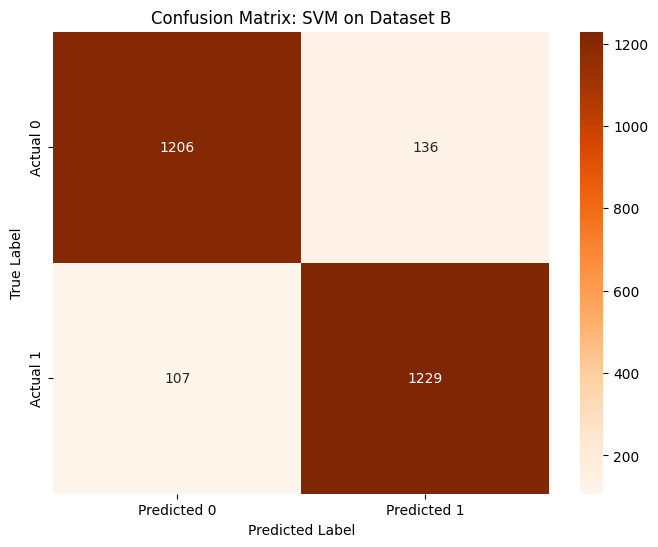

In [ ]:
plt.figure(figsize=(8, 6))
cm_svm_b = confusion_matrix(y_test_b, svm_b_preds)
sns.heatmap(cm_svm_b, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix: SVM on Dataset B')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")

In [ ]:
f1_metric = load("f1")
acc_metric = load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")
    acc = acc_metric.compute(predictions=predictions, references=labels)
    return {"f1": f1["f1"], "accuracy": acc["accuracy"]}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
def cap_text(text, max_words=50):
    words = str(text).split()
    return ' '.join(words[:max_words])

df_a_capped = df_a.copy()
df_a_capped['text'] = df_a_capped['text'].apply(lambda x: cap_text(x, 50))

train_a_capped, test_a_capped = train_test_split(
    df_a_capped,
    test_size=0.2,
    random_state=SEED,
    stratify=df_a_capped['label']
)

train_ds_a_capped = Dataset.from_pandas(train_a_capped[['text', 'label']].reset_index(drop=True))
test_ds_a_capped  = Dataset.from_pandas(test_a_capped[['text', 'label']].reset_index(drop=True))

train_ds_a_capped = train_ds_a_capped.map(tokenize_fn, batched=True)
test_ds_a_capped  = test_ds_a_capped.map(tokenize_fn, batched=True)

train_ds_a_capped.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_ds_a_capped.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

model_a_capped = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    num_labels=2
)
model_a_capped.to(DEVICE)

training_args_a_capped = TrainingArguments(
    output_dir="./exp_a_capped",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    seed=SEED,
    logging_steps=50,
    report_to="none",
)

trainer_a_capped = Trainer(
    model=model_a_capped,
    args=training_args_a_capped,
    train_dataset=train_ds_a_capped,
    eval_dataset=test_ds_a_capped,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer_a_capped.train()

results_a_capped = trainer_a_capped.evaluate(test_ds_a_capped)
f1_capped = results_a_capped['eval_f1']
print(f"Exp 5 (Capped at 50 words) F1: {f1_capped:.4f}")
print(f"Exp 1 (Full-length)        F1: 0.9287")
print(f"Drop: {0.9287 - f1_capped:.4f}")

Map:   0%|          | 0/7388 [00:00<?, ? examples/s]

Map:   0%|          | 0/1847 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.168986,0.323887,0.913900,0.913914
2,0.135771,0.345299,0.921485,0.921494
3,0.111541,0.358983,0.919831,0.919870


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Exp 5 (Capped at 50 words) F1: 0.9220
Exp 1 (Full-length)        F1: 0.9287
Drop: 0.0067


/tmp/ipykernel_4972/3244811810.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=values, palette='coolwarm')


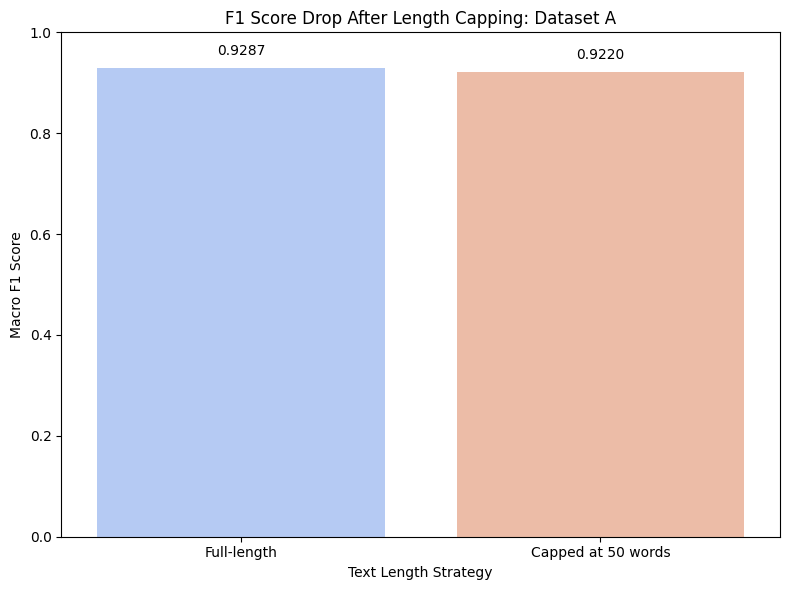

In [ ]:
labels = ['Full-length', 'Capped at 50 words']
values = [0.9287, f1_capped]

plt.figure(figsize=(8, 6))
sns.barplot(x=labels, y=values, palette='coolwarm')
plt.title('F1 Score Drop After Length Capping: Dataset A')
plt.xlabel('Text Length Strategy')
plt.ylabel('Macro F1 Score')
plt.ylim(0, 1)
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()